# Ataque de Grover contra el S-AES

El notebook se diferencia en dos secciones

## Implementación cuántica del S-AES (Simplified AES)

Basada en:
> Escanez-Exposito & Caballero-Gil (2026). *Quantum simulation of Boolean logic, digital circuits, and cryptographic schemes*. Journal of Logic and Computation. DOI: [10.1093/jigpal/jzaf019](https://academic.oup.com/jigpal/article/34/1/jzaf019/8443240)

El S-AES opera sobre bloques de **16 bits** con **2 rondas**, usando nibbles de 4 bits.

**Representación del estado** (little-endian Qiskit):
- `state[0..3]`  = $n_3$ (nibble menos significativo)
- `state[4..7]`  = $n_2$
- `state[8..11]` = $n_1$
- `state[12..15]`= $n_0$ (nibble más significativo)

**Registros del circuito** (48 qubits total):
- `state` (16): estado actual del mensaje
- `aux_sub` (16): auxiliar para SubNibbles (reversibilidad via Bennett)
- `aux_mc` (16): auxiliar para MixColumns

Además, se realiza una comprobación contra el cifrado clásico.

## Implementación del algoritmo de Grover presentada en la memoria

Para poder abordar el ataque ha sido necesario sacrificar realismo, de esta forma se dan por conocidos 3 de los nibbles y, mediante Grover, se recupera el cuarto. La implementación permite modificar los bits conocidos de modo que es posible controlar el tamaño de búsqueda, pero a costa de profundidad del circuito. Para la ejecución de este modelo, que involucra 105 qubits, se ha utilizado el simulador `matrix_product_state` (MPS), capaz de gestionar la complejidad del entrelazamiento mediante el truncamiento controlado de la dimensión de enlace.

> El código ha sido refactorizado usando Claude Sonnet 4.6 y Gemini 3.1 pro.

## Instalación e importaciones

In [ ]:
%pip install qiskit qiskit-aer numpy -q

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
import time

# Construcción del S-AES cuántico y verificación de resultados

## Tablas y operaciones en $\mathrm{GF}(2^4)$

La S-Box del S-AES está definida en $\mathrm{GF}(2^4)$ con polinomio irreducible $x^4+x+1$.
La MixColumns usa la matriz $\begin{pmatrix}1&4\\4&1\end{pmatrix}$ en $\mathrm{GF}(2^4)$.

In [ ]:
# S-Box del S-AES (Musa et al. 2003)
SBOX_INT = [0x9, 0x4, 0xA, 0xB, 0xD, 0x1, 0x8, 0x5,
            0x6, 0x2, 0x0, 0x3, 0xC, 0xE, 0xF, 0x7]
SBOX     = {i: SBOX_INT[i] for i in range(16)}
SBOX_INV = {v: k for k, v in SBOX.items()}

# Constantes de ronda
RCON = {1: 0x80, 2: 0x30}

def gf_mult(a, b, mod=0x13):
    """Multiplicación en GF(2^4) con polinomio irreducible x^4+x+1."""
    result = 0
    for _ in range(4):
        if b & 1: result ^= a
        hi = a & 0x8
        a  = (a << 1) & 0xF
        if hi: a ^= (mod & 0xF)
        b >>= 1
    return result

print("S-Box S-AES:")
for row in range(4):
    print("  " + "  ".join(f"{row*4+col:04b}->{SBOX_INT[row*4+col]:04b}"
                           for col in range(4)))
print(f"\nVerificación GF(2^4): 4×4 = {gf_mult(4,4):#x} (= x^4 mod x^4+x+1 = x+1 = 3)")

S-Box S-AES:
  0000->1001  0001->0100  0010->1010  0011->1011
  0100->1101  0101->0001  0110->1000  0111->0101
  1000->0110  1001->0010  1010->0000  1011->0011
  1100->1100  1101->1110  1110->1111  1111->0111

Verificación GF(2^4): 4×4 = 0x3 (= x^4 mod x^4+x+1 = x+1 = 3)


## KeyExpansion (clásica)

In [ ]:
def key_expansion(key):
    """Genera 3 subclaves de 16 bits. Implementación clásica (offline)."""
    def sub_word(w): return (SBOX[(w>>4)&0xF] << 4) | SBOX[w&0xF]
    def rot_word(w): return ((w&0xF) << 4) | ((w>>4)&0xF)

    w    = [0]*6
    w[0] = (key >> 8) & 0xFF
    w[1] =  key       & 0xFF
    w[2] = w[0] ^ RCON[1] ^ sub_word(rot_word(w[1]))
    w[3] = w[2] ^ w[1]
    w[4] = w[2] ^ RCON[2] ^ sub_word(rot_word(w[3]))
    w[5] = w[4] ^ w[3]
    return (w[0]<<8)|w[1], (w[2]<<8)|w[3], (w[4]<<8)|w[5]

K = 0x544A
k0, k1, k2 = key_expansion(K)
print(f"K  = {K:#06x}")
print(f"k0 = {k0:#06x}")
print(f"k1 = {k1:#06x}")
print(f"k2 = {k2:#06x}")

K  = 0x544a
k0 = 0x544a
k1 = 0xd993
k2 = 0x5bc8


## Implementación clásica de referencia

Implementación compacta del S-AES para verificar el circuito cuántico.

**Convención de nibbles**: $[n_0, n_1, n_2, n_3]$ donde $n_0$ es el nibble más significativo.

**ShiftRows**: intercambia $n_1$ y $n_3$ → $[n_0, n_3, n_2, n_1]$

**MixColumns**: opera por columnas $[n_0,n_1]$ y $[n_2,n_3]$ en $\mathrm{GF}(2^4)$.

In [ ]:
def saes_encrypt(P, K):
    """Cifrado S-AES clásico."""
    k0, k1, k2 = key_expansion(K)

    def nibs(x):      return [(x>>12)&0xF, (x>>8)&0xF, (x>>4)&0xF, x&0xF]
    def from_nibs(n): return (n[0]<<12)|(n[1]<<8)|(n[2]<<4)|n[3]
    def ark(s, k):    kn=nibs(k); return [s[i]^kn[i] for i in range(4)]
    def sub(s):       return [SBOX[x] for x in s]
    def shr(s):       return [s[0], s[3], s[2], s[1]]   # swap n1 y n3
    def mc(s):
        return [gf_mult(1,s[0]) ^ gf_mult(4,s[1]),      # n0' = n0 + 4*n1
                gf_mult(4,s[0]) ^ gf_mult(1,s[1]),      # n1' = 4*n0 + n1
                gf_mult(1,s[2]) ^ gf_mult(4,s[3]),      # n2' = n2 + 4*n3
                gf_mult(4,s[2]) ^ gf_mult(1,s[3])]      # n3' = 4*n2 + n3

    s = nibs(P)
    s = ark(s, k0)                       # Ronda inicial
    s = sub(s); s = shr(s); s = mc(s)   # Ronda 1
    s = ark(s, k1)
    s = sub(s); s = shr(s)              # Ronda 2 (sin MixColumns)
    s = ark(s, k2)
    return from_nibs(s)

# Test vectors
test_vectors = [(0xDF64, 0x544A), (0x0000, 0x0000),
                (0xFFFF, 0xFFFF), (0x1234, 0xABCD)]
print("S-AES clásico:")
for P, K in test_vectors:
    print(f"  P={P:#06x}, K={K:#06x} -> C={saes_encrypt(P,K):#06x}")

S-AES clásico:
  P=0xdf64, K=0x544a -> C=0xf4b6
  P=0x0000, K=0x0000 -> C=0x071e
  P=0xffff, K=0xffff -> C=0x5343
  P=0x1234, K=0xabcd -> C=0xab86


## Construcción del circuito cuántico



### SubNibbles (S-Box cuántica)
La S-Box se implementa como una función booleana: para cada patrón de entrada,
las puertas MCX activan los bits de salida correspondientes en `aux_sub`.
El truco de Bennett garantiza la reversibilidad:
`SBOX` → `SWAP(state, aux_sub)` → `SBOX_INV`

In [ ]:
def build_sbox_nibble():
    """
    S-Box cuántica para un nibble de 4 bits.
    qin (4): entrada, qout (4): salida (inicialmente |0⟩).
    Usa MCX con ctrl_state en big-endian para lista [q0,q1,q2,q3].
    """
    qin  = QuantumRegister(4, 'in')
    qout = QuantumRegister(4, 'out')
    qc   = QuantumCircuit(qin, qout, name='SBOX')
    for inp, out in enumerate(SBOX_INT):
        if out == 0: continue
        ctrl_state = format(inp, '04b')
        for bit in range(4):
            if (out >> bit) & 1:
                qc.mcx(list(qin), qout[bit], ctrl_state=ctrl_state)
    return qc

def build_sbox_inv_nibble():
    """S-Box inversa cuántica para un nibble."""
    qin  = QuantumRegister(4, 'in')
    qout = QuantumRegister(4, 'out')
    qc   = QuantumCircuit(qin, qout, name='SBOX_INV')
    for inp, out in SBOX_INV.items():
        if out == 0: continue
        ctrl_state = format(inp, '04b')
        for bit in range(4):
            if (out >> bit) & 1:
                qc.mcx(list(qin), qout[bit], ctrl_state=ctrl_state)
    return qc

# Verificar S-Box cuántica
from qiskit.quantum_info import Statevector
sbox_q = build_sbox_nibble()
print("Verificación S-Box cuántica:")
all_ok = True
for inp in range(16):
    qc_v = QuantumCircuit(8)
    for i in range(4):
        if (inp >> i) & 1: qc_v.x(i)
    qc_v.append(sbox_q, range(8))
    out = (np.argmax(np.abs(Statevector(qc_v).data)**2) >> 4) & 0xF
    if out != SBOX[inp]:
        print(f"  FALLO: {inp:#x} -> {out:#x} (esperado {SBOX[inp]:#x})")
        all_ok = False
print(f"  {'✓ Todos correctos' if all_ok else '✗ Hay fallos'}")
print(f"  Profundidad: {sbox_q.depth()}, Puertas: {sbox_q.size()}")

Verificación S-Box cuántica:
  ✓ Todos correctos
  Profundidad: 32, Puertas: 32


### ShiftRows
Intercambia semánticamente $n_1$ y $n_3$.
En el circuito: `SWAP(state[8..11], state[0..3])`.

In [ ]:
def build_shift_rows():
    """ShiftRows: SWAP entre n1 (state[8..11]) y n3 (state[0..3])."""
    state = QuantumRegister(16, 'state')
    qc    = QuantumCircuit(state)
    for i in range(4):
        qc.swap(state[8+i], state[0+i])
    return qc

sr_qc = build_shift_rows()
print(f"ShiftRows: depth={sr_qc.depth()}, gates={sr_qc.size()}")
print(sr_qc.draw(output='text', fold=-1))

ShiftRows: depth=1, gates=4
                      
 state_0: ─X──────────
           │          
 state_1: ─┼──X───────
           │  │       
 state_2: ─┼──┼──X────
           │  │  │    
 state_3: ─┼──┼──┼──X─
           │  │  │  │ 
 state_4: ─┼──┼──┼──┼─
           │  │  │  │ 
 state_5: ─┼──┼──┼──┼─
           │  │  │  │ 
 state_6: ─┼──┼──┼──┼─
           │  │  │  │ 
 state_7: ─┼──┼──┼──┼─
           │  │  │  │ 
 state_8: ─X──┼──┼──┼─
              │  │  │ 
 state_9: ────X──┼──┼─
                 │  │ 
state_10: ───────X──┼─
                    │ 
state_11: ──────────X─
                      
state_12: ────────────
                      
state_13: ────────────
                      
state_14: ────────────
                      
state_15: ────────────
                      


### MixColumns
Mezcla lineal en $\mathrm{GF}(2^4)$ con $\begin{pmatrix}1&4\\4&1\end{pmatrix}$.

La multiplicación por 4 ($=x^2$ en $\mathrm{GF}(2^4)$ con $x^4+x+1$) se implementa
mediante el mapeo lineal verificado:
$$[b_3,b_2,b_1,b_0] \xrightarrow{\times 4} [b_1,\, b_0\oplus b_3,\, b_3\oplus b_2,\, b_2]$$

**Mapeo de columnas post-ShiftRows** (en qubits):
- col0: `[state[12..15], state[8..11]]` → $[n_0, n_1]$
- col1: `[state[4..7],   state[0..3]]`  → $[n_2, n_3]$

In [ ]:
def apply_mult4(qc, src, tgt):
    """
    tgt ^= 4*src en GF(2^4) con x^4+x+1.
    Mapeo verificado: [a2, a3^a2, a0^a3, a1] (little-endian)
    """
    qc.cx(src[2], tgt[0])
    qc.cx(src[3], tgt[1]); qc.cx(src[2], tgt[1])
    qc.cx(src[0], tgt[2]); qc.cx(src[3], tgt[2])
    qc.cx(src[1], tgt[3])

def build_mix_columns():
    """
    MixColumns: opera sobre pares de nibbles en GF(2^4).
    Escribe el resultado en aux_mc y hace SWAP con state.
    Mapeo de columnas post-ShiftRows:
      col0: [state[12..15], state[8..11]] -> n0' en aux_mc[12..15], n1' en aux_mc[8..11]
      col1: [state[4..7],   state[0..3]]  -> n2' en aux_mc[4..7],   n3' en aux_mc[0..3]
    """
    state  = QuantumRegister(16, 'state')
    aux_mc = QuantumRegister(16, 'aux_mc')
    qc     = QuantumCircuit(state, aux_mc)

    # col0: n0'=na0+4*nb0, n1'=4*na0+nb0
    na0 = [state[12+i]  for i in range(4)]
    nb0 = [state[8+i]   for i in range(4)]   # post-SR: state[8..11] tiene n1
    oa0 = [aux_mc[12+i] for i in range(4)]   # n0'
    ob0 = [aux_mc[8+i]  for i in range(4)]   # n1'
    for i in range(4): qc.cx(na0[i], oa0[i])
    apply_mult4(qc, nb0, oa0)
    for i in range(4): qc.cx(nb0[i], ob0[i])
    apply_mult4(qc, na0, ob0)

    # col1: n2'=na1+4*nb1, n3'=4*na1+nb1
    na1 = [state[4+i]   for i in range(4)]
    nb1 = [state[0+i]   for i in range(4)]   # post-SR: state[0..3] tiene n3
    oa1 = [aux_mc[4+i]  for i in range(4)]   # n2'
    ob1 = [aux_mc[0+i]  for i in range(4)]   # n3'
    for i in range(4): qc.cx(na1[i], oa1[i])
    apply_mult4(qc, nb1, oa1)
    for i in range(4): qc.cx(nb1[i], ob1[i])
    apply_mult4(qc, na1, ob1)

    for i in range(16): qc.swap(aux_mc[i], state[i])
    return qc

mc_qc = build_mix_columns()
print(f"MixColumns: {mc_qc.num_qubits} qubits, depth={mc_qc.depth()}, gates={mc_qc.size()}")

# Verificar MixColumns sobre columna 0 aislada
print("\nVerificación MixColumns (todas las combinaciones de una columna):")
all_ok = True
for n0 in range(16):
    for n1 in range(16):
        qc_v = QuantumCircuit(16)
        for i in range(4):
            if (n0>>i)&1: qc_v.x(12+i)
            if (n1>>i)&1: qc_v.x(8+i)
        na0=[qc_v.qubits[12+i] for i in range(4)]
        nb0=[qc_v.qubits[8+i]  for i in range(4)]
        oa0=[qc_v.qubits[0+i]  for i in range(4)]
        ob0=[qc_v.qubits[4+i]  for i in range(4)]
        for i in range(4): qc_v.cx(na0[i],oa0[i])
        apply_mult4(qc_v,nb0,oa0)
        for i in range(4): qc_v.cx(nb0[i],ob0[i])
        apply_mult4(qc_v,na0,ob0)
        sv=Statevector(qc_v)
        idx=np.argmax(np.abs(sv.data)**2)
        got0=idx&0xF; got1=(idx>>4)&0xF
        exp0=gf_mult(1,n0)^gf_mult(4,n1)
        exp1=gf_mult(4,n0)^gf_mult(1,n1)
        if got0!=exp0 or got1!=exp1:
            all_ok=False
            print(f"  FALLO: ({n0:#x},{n1:#x})->({got0:#x},{got1:#x}) exp=({exp0:#x},{exp1:#x})")
print(f"  {'✓ Todos correctos (256 pares)' if all_ok else '✗ Hay fallos'}")

MixColumns: 32 qubits, depth=7, gates=56

Verificación MixColumns (todas las combinaciones de una columna):
  ✓ Todos correctos (256 pares)


## Circuito S-AES completo

In [ ]:
def build_saes_circuit(P, K):
    """
    Circuito S-AES cuántico completo (48 qubits).
    Las subclaves se pasan clásicamente para reducir el número de qubits.
    """
    k0, k1, k2 = key_expansion(K)

    state   = QuantumRegister(16, 'state')
    aux_sub = QuantumRegister(16, 'aux_sub')
    aux_mc  = QuantumRegister(16, 'aux_mc')
    cr      = ClassicalRegister(16, 'c')
    qc      = QuantumCircuit(state, aux_sub, aux_mc, cr)

    sbox     = build_sbox_nibble()
    sbox_inv = build_sbox_inv_nibble()

    def apply_sub(qc):
        """SubNibbles reversible via truco de Bennett."""
        # 1. Computar SBOX en aux_sub
        for n in range(4):
            qin  = [state[n*4+i]    for i in range(4)]
            qout = [aux_sub[n*4+i]  for i in range(4)]
            qc.append(sbox, qin+qout)
        # 2. SWAP: state <-> aux_sub  (state = SBOX(input), aux_sub = input)
        for i in range(16): qc.swap(state[i], aux_sub[i])
        # 3. Descomputar: SBOX_INV limpia aux_sub a |0⟩
        for n in range(4):
            qin  = [state[n*4+i]    for i in range(4)]
            qout = [aux_sub[n*4+i]  for i in range(4)]
            qc.append(sbox_inv, qin+qout)

    def apply_sr(qc):
        """ShiftRows: SWAP(state[8..11], state[0..3])."""
        for i in range(4): qc.swap(state[8+i], state[0+i])

    def apply_mc(qc):
        """
        MixColumns con mapeo de columnas correcto post-ShiftRows.
        Post-SR: state[12..15]=n0, state[8..11]=n1, state[4..7]=n2, state[0..3]=n3
        """
        na0 = [state[12+i]  for i in range(4)]
        nb0 = [state[8+i]   for i in range(4)]
        oa0 = [aux_mc[12+i] for i in range(4)]
        ob0 = [aux_mc[8+i]  for i in range(4)]
        for i in range(4): qc.cx(na0[i], oa0[i])
        apply_mult4(qc, nb0, oa0)
        for i in range(4): qc.cx(nb0[i], ob0[i])
        apply_mult4(qc, na0, ob0)

        na1 = [state[4+i]   for i in range(4)]
        nb1 = [state[0+i]   for i in range(4)]
        oa1 = [aux_mc[4+i]  for i in range(4)]
        ob1 = [aux_mc[0+i]  for i in range(4)]
        for i in range(4): qc.cx(na1[i], oa1[i])
        apply_mult4(qc, nb1, oa1)
        for i in range(4): qc.cx(nb1[i], ob1[i])
        apply_mult4(qc, na1, ob1)

        for i in range(16): qc.swap(aux_mc[i], state[i])

    # ── Inicializar plaintext ─────────────────────────────────────────────────
    for i in range(16):
        if (P >> i) & 1: qc.x(state[i])
    qc.barrier()

    # ── AddRoundKey(k0) ───────────────────────────────────────────────────────
    for i in range(16):
        if (k0 >> i) & 1: qc.x(state[i])
    qc.barrier(label='ARK0')

    # ── Ronda 1 ───────────────────────────────────────────────────────────────
    apply_sub(qc); qc.barrier(label='Sub1')
    apply_sr(qc);  qc.barrier(label='SR1')
    apply_mc(qc);  qc.barrier(label='MC1')
    for i in range(16):
        if (k1 >> i) & 1: qc.x(state[i])
    qc.barrier(label='ARK1')

    # ── Ronda 2 (sin MixColumns) ──────────────────────────────────────────────
    apply_sub(qc); qc.barrier(label='Sub2')
    apply_sr(qc);  qc.barrier(label='SR2')
    for i in range(16):
        if (k2 >> i) & 1: qc.x(state[i])
    qc.barrier(label='ARK2')

    qc.measure(state, cr)
    return qc

qc_info = build_saes_circuit(0xDF64, 0x544A)
print(f"Circuito S-AES:")
print(f"  Qubits     : {qc_info.num_qubits}")
print(f"  Profundidad: {qc_info.decompose().depth()}")
print(f"  Puertas    : {qc_info.size()}")

Circuito S-AES:
  Qubits     : 48
  Profundidad: 154
  Puertas    : 161


## Simulación y verificación

In [ ]:
sim = AerSimulator(method='matrix_product_state')

P_test = 0xDF64
K_test = 0x544A

print("=" * 52)
print(" COMPARACIÓN S-AES: CLÁSICO vs CUÁNTICO")
print("=" * 52)
print(f"Texto Plano (P) : {P_test:#06x} = {P_test:016b}")
print(f"Clave (K)       : {K_test:#06x} = {K_test:016b}\n")

# Clásico
t0 = time.time()
C_c = saes_encrypt(P_test, K_test)
t_c = time.time() - t0
print(f"--- RESULTADO CLÁSICO ---")
print(f"Cifrado (C)     : {C_c:#06x} = {C_c:016b}")
print(f"Tiempo          : {t_c:.6f} s\n")

# Cuántico
print("--- RESULTADO CUÁNTICO ---")
qc = build_saes_circuit(P_test, K_test)
print(f"Qubits totales  : {qc.num_qubits}")
qct = transpile(qc, sim)
t0 = time.time()
result = sim.run(qct, shots=1).result()
t_q = time.time() - t0
C_q = int(list(result.get_counts().keys())[0].split(' ')[-1], 2)
print(f"Cifrado (C)     : {C_q:#06x} = {C_q:016b}")
print(f"Tiempo          : {t_q:.6f} s\n")

print("=" * 52)
if C_c == C_q:
    print("✓ ÉXITO — Cuántico coincide con clásico")
else:
    print("✗ DISCREPANCIA")
print("=" * 52)

 COMPARACIÓN S-AES: CLÁSICO vs CUÁNTICO
Texto Plano (P) : 0xdf64 = 1101111101100100
Clave (K)       : 0x544a = 0101010001001010

--- RESULTADO CLÁSICO ---
Cifrado (C)     : 0xf4b6 = 1111010010110110
Tiempo          : 0.000150 s

--- RESULTADO CUÁNTICO ---
Qubits totales  : 48
Cifrado (C)     : 0xf4b6 = 1111010010110110
Tiempo          : 0.534210 s

✓ ÉXITO — Cuántico coincide con clásico


## Verificación con múltiples vectores de prueba

In [ ]:
print("=== Verificación multi-vector ===")
test_vectors = [
    (0xDF64, 0x544A),
    (0x0000, 0x0000),
    (0xFFFF, 0xFFFF),
    (0x1234, 0xABCD),
    (0x2D55, 0x4A61),
    (0xABCD, 0x1234),
    (0x6F6B, 0xCAFE),
]
all_ok = True
for P, K in test_vectors:
    C_c = saes_encrypt(P, K)
    qc  = build_saes_circuit(P, K)
    qct = transpile(qc, sim)
    C_q = int(list(sim.run(qct, shots=1).result().get_counts()
                   .keys())[0].split(' ')[-1], 2)
    ok  = C_c == C_q
    if not ok: all_ok = False
    print(f"  P={P:#06x}, K={K:#06x} -> C={C_c:#06x}  {'✓' if ok else '✗'}")

print(f"\n{'✓ Todos los test vectors correctos' if all_ok else '✗ Hay discrepancias'}")

=== Verificación multi-vector ===
  P=0xdf64, K=0x544a -> C=0xf4b6  ✓
  P=0x0000, K=0x0000 -> C=0x071e  ✓
  P=0xffff, K=0xffff -> C=0x5343  ✓
  P=0x1234, K=0xabcd -> C=0xab86  ✓
  P=0x2d55, K=0x4a61 -> C=0x414c  ✓
  P=0xabcd, K=0x1234 -> C=0xe584  ✓
  P=0x6f6b, K=0xcafe -> C=0x40df  ✓

✓ Todos los test vectors correctos


## Visualización del circuito

In [ ]:
print("Circuito S-AES (vista compacta con etiquetas de ronda):")
qc_vis = build_saes_circuit(0xDF64, 0x544A)
print(qc_vis.draw(output='text', fold=120, plot_barriers=True,
                  initial_state=False))

Circuito S-AES (vista compacta con etiquetas de ronda):
                  ░       ARK0 ┌───────┐                                                                           »
   state_0: ──────░────────░───┤0      ├────────────────────────────X──────────────────────────────────────────────»
                  ░ ┌───┐  ░   │       │                            │                                              »
   state_1: ──────░─┤ X ├──░───┤1      ├────────────────────────────┼──X───────────────────────────────────────────»
            ┌───┐ ░ └───┘  ░   │       │                            │  │                                           »
   state_2: ┤ X ├─░────────░───┤2      ├────────────────────────────┼──┼──X────────────────────────────────────────»
            └───┘ ░ ┌───┐  ░   │       │                            │  │  │                                        »
   state_3: ──────░─┤ X ├──░───┤3      ├────────────────────────────┼──┼──┼──X─────────────────────────────────────»
        

# Ataque usando Grover

## Puerta SAES

Código adaptado para Grover

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister

def build_quantum_saes_operator():
    # ── 1. Inicializar Registros (104 qubits totales para el U_SAES) ──
    k0_reg  = QuantumRegister(16, 'k0')
    k1_reg  = QuantumRegister(16, 'k1')
    k2_reg  = QuantumRegister(16, 'k2')
    state   = QuantumRegister(16, 'state')
    aux_sub = QuantumRegister(16, 'aux_sub')
    aux_mc  = QuantumRegister(16, 'aux_mc')
    aux_key = QuantumRegister(8,  'aux_key')

    qc = QuantumCircuit(k0_reg, k1_reg, k2_reg, state, aux_sub, aux_mc, aux_key, name="U_SAES")

    # ── 2. Convertir tus funciones verificadas en Instrucciones (Cajas Negras) ──
    sbox_inst     = build_sbox_nibble().to_instruction(label="SBOX")
    sbox_inv_inst = build_sbox_inv_nibble().to_instruction(label="SBOX_INV")
    sr_inst       = build_shift_rows().to_instruction(label="ShiftRows")
    mc_inst       = build_mix_columns().to_instruction(label="MixColumns")

    # ── 3. Lógica de SubNibbles (Aplica tu SBOX a todo el estado) ──
    def apply_sub_bytes(target_reg, aux_r):
        """Aplica SubNibbles a los 16 bits usando el truco de Bennett."""
        # 1. Computar
        for n in range(4):
            qin  = [target_reg[n*4+i] for i in range(4)]
            qout = [aux_r[n*4+i]      for i in range(4)]
            qc.append(sbox_inst, qin + qout)
        # 2. SWAP
        for i in range(16):
            qc.swap(target_reg[i], aux_r[i])
        # 3. Descomputar (Limpieza)
        for n in range(4):
            qin  = [target_reg[n*4+i] for i in range(4)]
            qout = [aux_r[n*4+i]      for i in range(4)]
            qc.append(sbox_inv_inst, qin + qout)

    # ── 4. Key Schedule Cuántico (Usando tu SBOX) ──
    def quantum_key_expansion(source_key, target_key, aux_r, rcon_val):
        """Expansión de clave con el bug de descomputación ya corregido."""
        qin_0  = [source_key[i] for i in range(4)]
        qout_0 = [aux_r[i]      for i in range(4)]
        qc.append(sbox_inst, qin_0 + qout_0) # SBOX Nibble derecho

        qin_1  = [source_key[4+i] for i in range(4)]
        qout_1 = [aux_r[4+i]      for i in range(4)]
        qc.append(sbox_inst, qin_1 + qout_1) # SBOX Nibble izquierdo

        for i in range(8): qc.cx(source_key[8+i], target_key[8+i]) # Copiar w0

        # RotNib + XOR
        for i in range(4):
            qc.cx(aux_r[i], target_key[12+i])
            qc.cx(aux_r[4+i], target_key[8+i])

        # RCON
        if rcon_val == 0x80: qc.x(target_key[15])
        elif rcon_val == 0x30:
            qc.x(target_key[13]); qc.x(target_key[12])

        # w3 = w2 ^ w1
        for i in range(8):
            qc.cx(target_key[8+i], target_key[i])
            qc.cx(source_key[i], target_key[i])

        # Limpieza: Como source_key no cambió, aplicar SBOX de nuevo limpia aux_r a |0>
        qc.append(sbox_inst, qin_0 + qout_0)
        qc.append(sbox_inst, qin_1 + qout_1)

    # ── 5. ENSAMBLAJE FINAL DEL CIRCUITO S-AES ────────────────────────────────

    # Expansión de claves
    quantum_key_expansion(k0_reg, k1_reg, aux_key, 0x80)
    quantum_key_expansion(k1_reg, k2_reg, aux_key, 0x30)

    # AddRoundKey 0
    for i in range(16): qc.cx(k0_reg[i], state[i])

    # Ronda 1
    apply_sub_bytes(state, aux_sub)
    qc.append(sr_inst, list(state))
    qc.append(mc_inst, list(state) + list(aux_mc))
    for i in range(16): qc.cx(k1_reg[i], state[i])

    # Ronda 2
    apply_sub_bytes(state, aux_sub)
    qc.append(sr_inst, list(state))
    for i in range(16): qc.cx(k2_reg[i], state[i])

    return qc

# ── Generar el Operador Final ──
qc_saes_modular = build_quantum_saes_operator()
saes_gate = qc_saes_modular.to_instruction(label="U_SAES")
saes_gate_inv = qc_saes_modular.inverse().to_instruction(label="U_SAES_dg")

## Oráculo

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

def build_oracle(C_expected, saes_inst, saes_inv_inst):
    """Oráculo de Grover"""
    # Registros exactos que requiere tu U_SAES
    k0_reg  = QuantumRegister(16, 'k0')
    k1_reg  = QuantumRegister(16, 'k1')
    k2_reg  = QuantumRegister(16, 'k2')
    state_reg = QuantumRegister(16, 'p') # state_reg
    aux_sub = QuantumRegister(16, 'aux_sub')
    aux_mc  = QuantumRegister(16, 'aux_mc')
    aux_key = QuantumRegister(8,  'aux_key')
    minus_qubit = QuantumRegister(1, 'minus')

    oracle = QuantumCircuit(k0_reg, k1_reg, k2_reg, state_reg, aux_sub, aux_mc, aux_key, minus_qubit, name="Oracle")

    # Lista de qubits en el orden exacto para U_SAES
    saes_qubits = list(k0_reg) + list(k1_reg) + list(k2_reg) + \
                  list(state_reg) + list(aux_sub) + list(aux_mc) + list(aux_key)

    # 1. Aplicar U_{S-AES}
    oracle.append(saes_inst, saes_qubits)

    # 2. Puertas X donde el criptograma C tiene un '0'
    for i in range(16):
        if (C_expected >> i) & 1 == 0:
            oracle.x(state_reg[i])

    # 3. Puerta NOT multi-controlada (MCX) sobre el estado |->
    oracle.mcx(list(state_reg), minus_qubit[0])

    # 4. Deshacer las puertas X
    for i in range(16):
        if (C_expected >> i) & 1 == 0:
            oracle.x(state_reg[i])

    # 5. Aplicar U_{S-AES}^\dagger (Uncomputation)
    oracle.append(saes_inv_inst, saes_qubits)

    return oracle.to_instruction()

## Difusor

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister

def build_dynamic_diffuser(num_qubits):
    """
    Construye un difusor de Grover dinámico para un número específico de qubits.
    """
    if num_qubits == 0:
        return QuantumCircuit(name="No_Diffuser").to_instruction()

    k_reg = QuantumRegister(num_qubits, 'k')
    diffuser = QuantumCircuit(k_reg, name=f"Difusor_{num_qubits}q")

    diffuser.h(k_reg)
    diffuser.x(k_reg)

    # Manejar el Phase Flip multicontrolado según el número de qubits
    if num_qubits > 1:
        diffuser.h(k_reg[-1])
        diffuser.mcx(list(k_reg[:-1]), k_reg[-1])
        diffuser.h(k_reg[-1])
    elif num_qubits == 1:
        # Si solo falta 1 bit por adivinar, el "multi-control" es solo una puerta Z
        diffuser.z(k_reg[0])

    diffuser.x(k_reg)
    diffuser.h(k_reg)

    return diffuser.to_instruction()

## Ensamblado

In [ ]:
import math
from qiskit import ClassicalRegister

def assemble_partial_grover(P_hex, C_hex, saes_inst, saes_inv_inst, bits_conocidos={}):
    """
    Ensambla el ataque de Grover asumiendo x bits conocidos de la clave maestra.

    Parámetros:
    - bits_conocidos: Diccionario {indice_bit: valor_bit}. Ej: {15: 1, 14: 0}
    """
    num_desconocidos = 16 - len(bits_conocidos)
    N = 2 ** num_desconocidos

    # ── 1. Calcular iteraciones óptimas ──
    if num_desconocidos > 0:
        n_iterations = math.floor(math.pi / 4 * math.sqrt(N))
    else:
        n_iterations = 0 # Si conocemos toda la clave, no hay nada que buscar

    print(f"Buscando {num_desconocidos} bits desconocidos.")
    print(f"Espacio de búsqueda (N) = {N} claves posibles.")
    print(f"Iteraciones óptimas de Grover: {n_iterations}")

    # ── 2. Declaración de Registros ──
    k0_reg  = QuantumRegister(16, 'k0')
    k1_reg  = QuantumRegister(16, 'k1')
    k2_reg  = QuantumRegister(16, 'k2')
    state   = QuantumRegister(16, 'state')
    aux_sub = QuantumRegister(16, 'aux_sub')
    aux_mc  = QuantumRegister(16, 'aux_mc')
    aux_key = QuantumRegister(8,  'aux_key')
    minus   = QuantumRegister(1,  'minus')

    # Solo medimos los bits que no conocemos (opcional, pero más limpio)
    # Aquí mediremos todos los 16 para ver la clave completa armada al final
    cr = ClassicalRegister(16, 'c_key')

    qc = QuantumCircuit(k0_reg, k1_reg, k2_reg, state, aux_sub, aux_mc, aux_key, minus, cr, name="Partial_Grover")

    # ── 3. Inicialización Dinámica de la Clave ──
    qubits_desconocidos = []

    for i in range(16):
        if i in bits_conocidos:
            # Bit conocido: Inicialización clásica determinista
            if bits_conocidos[i] == 1:
                qc.x(k0_reg[i])
        else:
            # Bit desconocido: Poner en superposición
            qc.h(k0_reg[i])
            qubits_desconocidos.append(k0_reg[i]) # Guardamos la referencia para el difusor

    # Inicializar Plaintext y Phase Kickback
    for i in range(16):
        if (P_hex >> i) & 1: qc.x(state[i])

    qc.x(minus)
    qc.h(minus)
    qc.barrier(label="Init")

    # ── 4. Construir bloques ──
    oracle_inst = build_oracle(C_hex, saes_inst, saes_inv_inst) # Usa tus 16 bits completos
    diffuser_inst = build_dynamic_diffuser(num_desconocidos)

    oracle_args = list(k0_reg) + list(k1_reg) + list(k2_reg) + \
                  list(state) + list(aux_sub) + list(aux_mc) + list(aux_key) + [minus[0]]

    # ── 5. Bucle Principal de Grover ──
    for iteration in range(n_iterations):
        qc.append(oracle_inst, oracle_args)

        # Solo pasamos los cables de los qubits desconocidos al difusor
        if num_desconocidos > 0:
            qc.append(diffuser_inst, qubits_desconocidos)

    # ── 6. Medición ──
    qc.measure(k0_reg, cr)

    return qc

## Ejecución

In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile


def ejecutar_grover(circuito, shots=1024):
    # max_parallel_threads=0 obliga a Qiskit a usar todos los núcleos de tu CPU
    simulador = AerSimulator(
        method='matrix_product_state',
        max_parallel_threads=0,
        matrix_product_state_max_bond_dimension=2**10,  # Aumenta el límite de entrelazamiento retenido
        matrix_product_state_truncation_threshold=1e-8 # Exige mayor precisión antes de recortar datos
    )

    print("Transpilando y optimizando el circuito...")
    puertas_permitidas = ['cx', 'id', 'rz', 'sx', 'x', 'ccx']

    circ_transpilado = transpile(
        circuito,
        basis_gates=puertas_permitidas,
        optimization_level=2
    )

    print(f"Circuito reducido a una profundidad de: {circ_transpilado.depth()} compuertas.")
    print(f"Ejecutando {shots} shots...")

    # Ejecutamos con la configuración acelerada
    resultado = simulador.run(circ_transpilado, shots=shots).result()
    conteos = resultado.get_counts()

    return conteos

# ── 1. VECTORES DE PRUEBA EXACTOS ──
P_conocido = 0xDF64  # Texto Plano: 1101111101100100
K_objetivo = 0x544A  # Clave Real:  0101010001001010
C_esperado = 0xF4B6  # Cifrado:     1111010010110110

# ── 2. CONFIGURACIÓN DEL ATAQUE PARCIAL ──
# Vamos a fijar los bits del 15 al 4 (los tres primeros nibbles: 5, 4, 4)
# Los bits 3, 2, 1 y 0 (el nibble 'A') quedarán fuera de este diccionario
# para que el circuito los ponga en superposición.
mis_bits_conocidos = {
    15: 0, 14: 1, 13: 0, 12: 1,  # Nibble 1 -> 5 (0101)
    11: 0, 10: 1,  9: 0,  8: 0,  # Nibble 2 -> 4 (0100)
     7: 0,  6: 1,  5: 0,  4: 0   # Nibble 3 -> 4 (0100)
}

print(f"Iniciando ataque contra P=0x{P_conocido:04X}, C=0x{C_esperado:04X}")
print("Ensamblando el circuito de Grover parcial...")

# ── 3. ENSAMBLADO DEL CIRCUITO ──
circuito_parcial = assemble_partial_grover(
    P_hex=P_conocido,
    C_hex=C_esperado,
    saes_inst=saes_gate,
    saes_inv_inst=saes_gate_inv,
    bits_conocidos=mis_bits_conocidos
)

# ── 4. EJECUCIÓN (Usando tu función) ──

shots = 2**9
conteos_resultado = ejecutar_grover(circuito_parcial, shots=shots)

# ── 5. ANÁLISIS DE RESULTADOS ──
print("\n" + "="*40)
print(" RESULTADOS DEL ATAQUE PARCIAL")
print("="*40)

conteos_ordenados = sorted(conteos_resultado.items(), key=lambda item: item[1], reverse=True)

for bin_str, count in conteos_ordenados:
    # Convertimos la cadena binaria a hexadecimal
    # Nota: Si usas Little Endian en tu lectura, podrías necesitar [::-1] en bin_str
    hex_val = hex(int(bin_str, 2)).upper().replace('0X', '0x')

    # Marcamos visualmente si encontró la clave correcta
    match_str = " <--- ¡CLAVE CORRECTA!" if hex_val == f"0x{K_objetivo:04X}" else ""
    prob = (count / shots) * 100

    print(f"Medición: {hex_val} ({bin_str}) | Frecuencia: {count}/{shots} ({prob:.1f}%){match_str}")

Iniciando ataque contra P=0xDF64, C=0xF4B6
Ensamblando el circuito de Grover parcial...
Buscando 4 bits desconocidos.
Espacio de búsqueda (N) = 16 claves posibles.
Iteraciones óptimas de Grover: 3
Transpilando y optimizando el circuito...
Circuito reducido a una profundidad de: 270228 compuertas.
Ejecutando 512 shots...

 RESULTADOS DEL ATAQUE PARCIAL
Medición: 0x544A (0101010001001010) | Frecuencia: 496/512 (96.9%) <--- ¡CLAVE CORRECTA!
Medición: 0x5449 (0101010001001001) | Frecuencia: 2/512 (0.4%)
Medición: 0x5441 (0101010001000001) | Frecuencia: 2/512 (0.4%)
Medición: 0x544E (0101010001001110) | Frecuencia: 2/512 (0.4%)
Medición: 0x5445 (0101010001000101) | Frecuencia: 2/512 (0.4%)
Medición: 0x5440 (0101010001000000) | Frecuencia: 2/512 (0.4%)
Medición: 0x5443 (0101010001000011) | Frecuencia: 1/512 (0.2%)
Medición: 0x5447 (0101010001000111) | Frecuencia: 1/512 (0.2%)
Medición: 0x544B (0101010001001011) | Frecuencia: 1/512 (0.2%)
Medición: 0x5448 (0101010001001000) | Frecuencia: 1/51

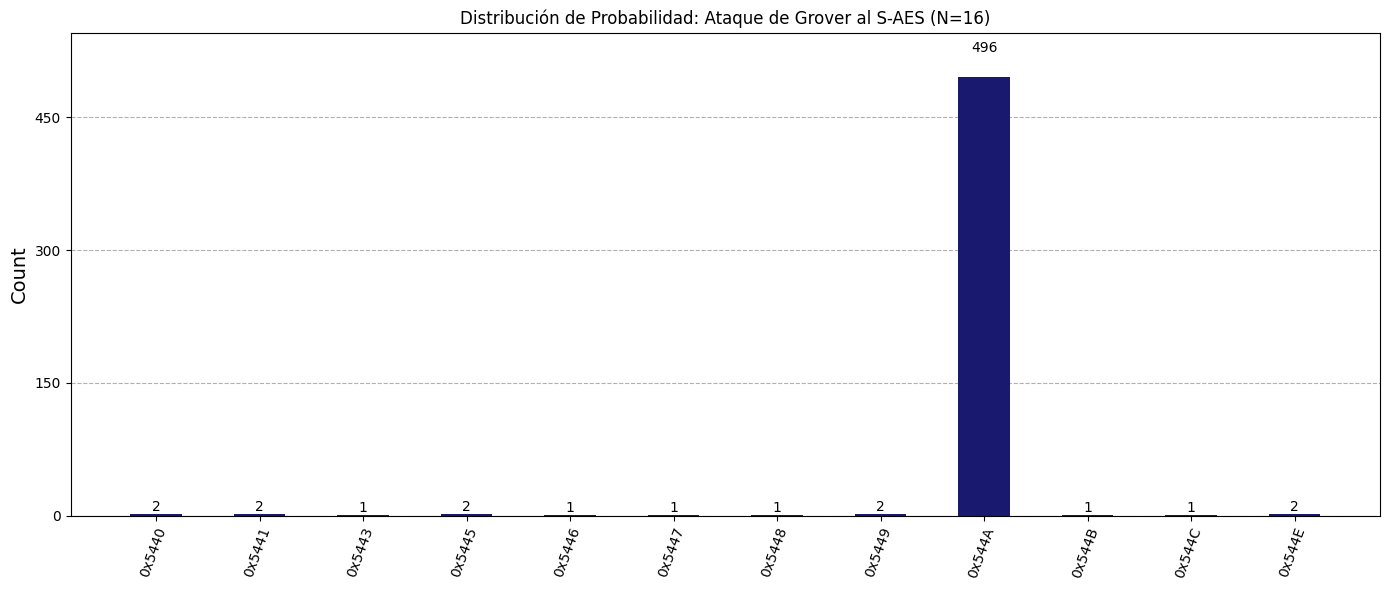

In [ ]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Convertir las claves del diccionario de binario a hexadecimal legible
conteos_hex = {}
for bin_str, count in conteos_resultado.items():
    # Convertir '0101010001001010' a '0x544A'
    hex_val = hex(int(bin_str, 2)).upper().replace('0X', '0x')
    conteos_hex[hex_val] = count

# 2. Ordenar el diccionario para que el más frecuente aparezca de forma destacada (Opcional pero recomendado para Qiskit)
conteos_hex_ordenados = dict(sorted(conteos_hex.items(), key=lambda item: item[1], reverse=True))

# 3. Generar el gráfico
figura = plot_histogram(
    conteos_hex_ordenados,
    title="Distribución de Probabilidad: Ataque de Grover al S-AES (N=16)",
    figsize=(14, 6),           # Hacerlo ancho para acomodar las 16 barras
    color='midnightblue',      # Un color elegante
    bar_labels=True            # Muestra el valor exacto sobre cada barra
)

# 4. Mostrar el gráfico
display(figura)